## Run 1
Taken over wavelength range 3,000 - 10,000 angstroms

no_of_packets: 1.0e+5
last_no_of_packets: 1.0e+5
no_of_virtual_packets: 3
Median SNR: 10.09
Average Relative Noise: 0.1074

no_of_packets: 1.0e+5
last_no_of_packets: 1.0e+5
no_of_virtual_packets: 6
Median SNR: 11.59
Average Relative Noise: 0.09472

In [2]:
# Investigate monte carlo noise
import matplotlib.pyplot as plt
import astropy.units as u
import pandas as pd
import numpy as np
import os
from IPython.display import display
%matplotlib widget

def show_active():
    fig = plt.gcf()
    display(fig)
    plt.close(fig)

folder_path_win = os.path.dirname('C:/Users/mikel/Desktop/noise_variation/')
folder_path_wsl = os.path.dirname('/mnt/c/Users/mikel/Desktop/noise_variation/')
folder_path = folder_path_win
runs_path = os.path.join(folder_path, 'parameters.log')

# Read data
runs_df = pd.read_json(runs_path, lines=True)
wav = None
seds = []
for run in runs_df.itertuples():
    sed_df = pd.read_csv(os.path.join(folder_path, str(run.id) + '_sed.csv'))
    seds.append(sed_df['L_density'].values)
    if wav is None:
        wav = sed_df['wavelength'].values

# Prepare data
def convert(v):
    return u.Quantity(v).value
X = runs_df.drop('id', axis=1).reset_index(drop=True).map(convert)
y = np.array(seds)

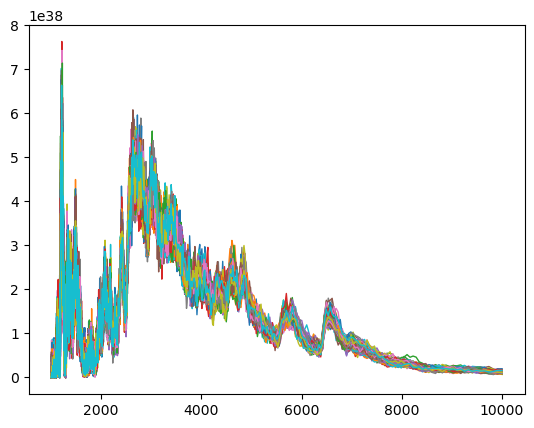

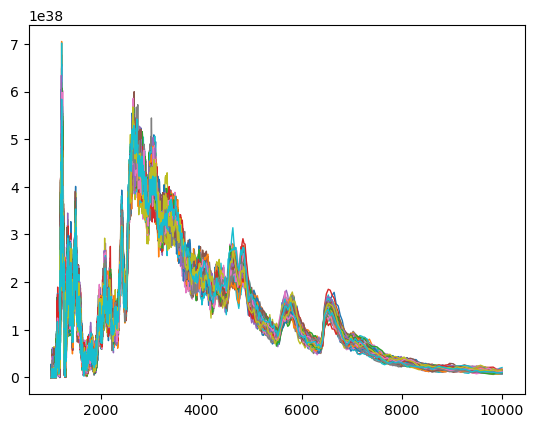

In [13]:
y1 = y[X['virtual_packets'] == 3.0]
y2 = y[X['virtual_packets'] == 6.0]

# View data
plt.figure()
for y_i in y1[:100]:
    plt.plot(wav, y_i, lw=1)
show_active()

plt.figure()
for y_i in y2[:100]:
    plt.plot(wav, y_i, lw=1)
show_active()

median SNR: 10.093541523319672
avg rel noise: 0.10740746111602331


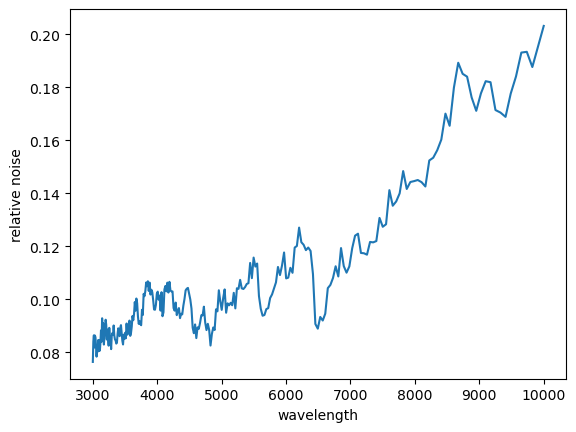

median SNR: 11.59548120762636
avg rel noise: 0.09471871391683884


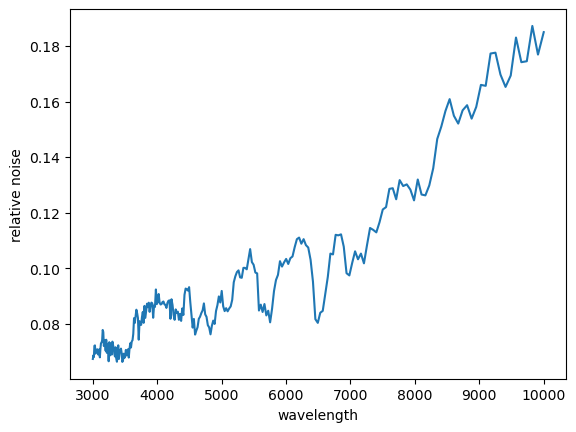

In [ ]:
# This is the region most spectra will be taken in
mask = wav > 3000

for y in [y1, y2]:
    mean = y.mean(axis=0)[mask]
    std = y.std(axis=0)[mask]

    snr = mean / std
    median_snr = np.median(snr)

    rel_noise = std / mean
    avg_rel_noise = np.mean(rel_noise)

    print('median SNR:', median_snr)
    print('avg rel noise:', avg_rel_noise)

    plt.plot(wav[mask], rel_noise)
    plt.xlabel('wavelength')
    plt.ylabel('relative noise')
    show_active()